In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch.nn as nn
import torch
import shutil
import os
import random
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torchvision import models
from torch import Generator
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


path = "/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Training"

## Checking GPU

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
torch.cuda.is_available()
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

cuda
GPU 0: Tesla T4
GPU 1: Tesla T4


## Params

In [3]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHS = 1 
N_CLASSES = 3
seedVal = 1
BATCH_SIZE = 32
MAX_IMAGES = 1900

## Merging Files

In [4]:
# Nuke Old Folder
output_dir = "/kaggle/working/datasets"
shutil.rmtree(output_dir, ignore_errors=True)  # won't error if it doesn't exist
os.makedirs(output_dir)
print("Folder reset!")

class_map = {
    "Apple": [
        "Apple 5", "Apple 8",
        "Apple 10", "Apple 11", "Apple 14",
        "Apple 17", "Apple 19",
        "Apple 22",
    ],
    "Banana": [
        "Banana 1", "Banana 3", "Banana 4",
        "Banana Lady Finger 1",
        "Banana Red 1"
    ],
    "Grape": [
        "Grape 1",
        "Grape Blue 1",
        "Grape Pink 1",
    ]
}
source_dir = f"{path}" 
output_dir = "/kaggle/working/datasets"

for class_name, folders in class_map.items():
    out_path = os.path.join(output_dir, class_name)
    os.makedirs(out_path)

    per_folder = MAX_IMAGES // len(folders)
    total_copied = 0

    for folder in folders:
        src = os.path.join(source_dir, folder)
        if not os.path.exists(src):
            print(f"  WARNING: {folder} not found, skipping")
            continue

        images = os.listdir(src)
        selected = random.sample(images, min(per_folder, len(images)))

        for img in selected:
            new_name = f"{folder}_{img}"
            shutil.copy(os.path.join(src, img), os.path.join(out_path, new_name))
            total_copied += 1

    print(f"{class_name}: {total_copied} images copied")

# Verify
print("\nFinal counts:")
for class_name in class_map:
    folder = os.path.join(output_dir, class_name)
    print(f"  {class_name}: {len(os.listdir(folder))} images")

Folder reset!
Apple: 1896 images copied
Banana: 1627 images copied
Grape: 1594 images copied

Final counts:
  Apple: 1896 images
  Banana: 1627 images
  Grape: 1594 images


## Formatting, Splitting Dataset, and Applying Transforms

In [5]:
transform_list_train = [
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15, fill=255),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
]
transform_list_valid = [ # for test and valid
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
]
transforms_train = transforms.Compose(transform_list_train)
transforms_val   = transforms.Compose(transform_list_valid)

# Two ImageFolders — same data, different transforms
train_data = datasets.ImageFolder(root="/kaggle/working/datasets", transform=transforms_train)
val_data  = datasets.ImageFolder(root="/kaggle/working/datasets", transform=transforms_val)

# Calculate sizes
train_size = int(0.70 * len(train_data))
valid_size = int(0.15 * len(train_data))
test_size  = len(train_data) - train_size - valid_size

# Split both with same seed so splits are identical
train_dataset, _, _            = random_split(train_data, [train_size, valid_size, test_size],
                                              generator=Generator().manual_seed(seedVal))
_, valid_dataset, test_dataset = random_split(val_data,  [train_size, valid_size, test_size],
                                              generator=Generator().manual_seed(seedVal))

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)  # ← False
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)  # ← False

print(f"Train: {len(train_dataset)} | Valid: {len(valid_dataset)} | Test: {len(test_dataset)}")

Train: 3581 | Valid: 767 | Test: 769


## Displaying Random Images for Debugging

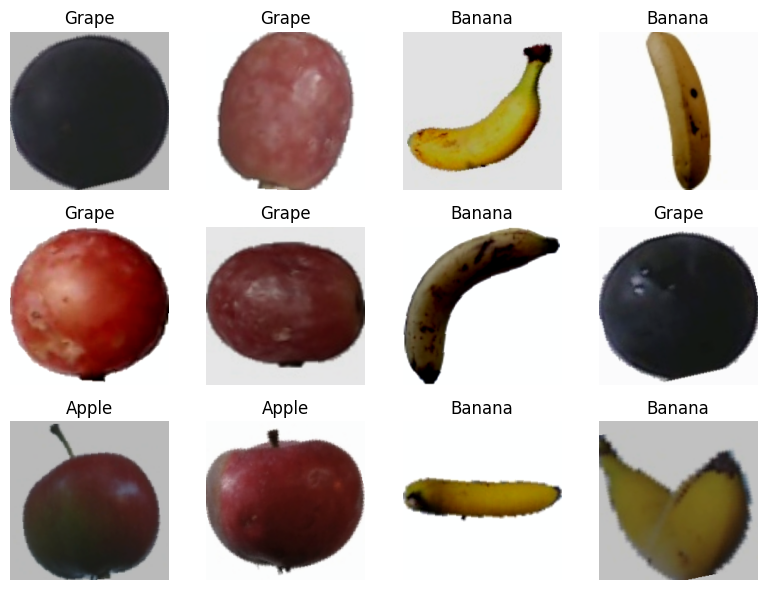

In [6]:
def show_batch(dataloader, class_names, num_images=12):
    images, labels = next(iter(dataloader))
    
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    
    fig, axes = plt.subplots(3, 4, figsize=(8, 6))
    axes = axes.flatten()
    
    for i in range(num_images):
        img = images[i].numpy().transpose(1, 2, 0)
        img = (img * std) + mean      # ← undo normalization
        img = np.clip(img, 0, 1)
        
        axes[i].imshow(img)
        axes[i].set_title(class_names[labels[i].item()])
        axes[i].axis("off")
    
    plt.tight_layout()
    plt.show()

class_names = ["Apple", "Banana", "Grape"]
show_batch(train_loader, class_names)

## Transfer Learning

In [7]:
model = models.resnet18(weights = models.ResNet18_Weights.DEFAULT)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace FInal layer
num_features = model.fc.in_features # input size of the final layer
model.fc = nn.Linear(num_features, N_CLASSES)
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


Linear(in_features=512, out_features=3, bias=True)


## Loss and Optimizer

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

loss_function = nn.CrossEntropyLoss()

# ONLY APPLY TO FINAL OUTPUT LAYER
optimizer = torch.optim.Adam(model.fc.parameters(), lr = 0.001)

## Training Loop

In [9]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs, device):
    
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    
    for epoch in range(num_epochs):
        # --- Training ---
        model.train()
        train_loss, train_correct = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss    += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()

        # --- Validation ---
        model.eval()
        val_loss, val_correct = 0, 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss    += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()

        # --- Stats ---
        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc  = train_correct / len(train_loader.dataset) * 100
        epoch_val_loss   = val_loss / len(valid_loader)
        epoch_val_acc    = val_correct / len(valid_loader.dataset) * 100

        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {epoch_train_loss:.4f} | "
              f"Train Acc: {epoch_train_acc:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f} | "
              f"Val Acc: {epoch_val_acc:.2f}%")

    return history

## Func Call

In [10]:
EPOCHES = 10
# Phase 1 — frozen backbone, train final layer only
print("Phase 1 Training...")
history_phase1 = train_model(model, train_loader, valid_loader,
                              loss_function, optimizer,
                              num_epochs=EPOCHES, device=device)

# Phase 2 — unfreeze everything and fine-tune
print("\nPhase 2 Fine-tuning...")
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)

history_phase2 = train_model(model, train_loader, valid_loader,
                              loss_function, optimizer,
                              num_epochs=EPOCHES, device=device)

Phase 1 Training...
Epoch 1/10 | Train Loss: 0.2851 | Train Acc: 92.80% | Val Loss: 0.1046 | Val Acc: 98.57%
Epoch 2/10 | Train Loss: 0.0820 | Train Acc: 98.91% | Val Loss: 0.0613 | Val Acc: 98.83%
Epoch 3/10 | Train Loss: 0.0475 | Train Acc: 99.33% | Val Loss: 0.0472 | Val Acc: 98.96%
Epoch 4/10 | Train Loss: 0.0384 | Train Acc: 99.61% | Val Loss: 0.0359 | Val Acc: 99.22%
Epoch 5/10 | Train Loss: 0.0342 | Train Acc: 99.36% | Val Loss: 0.0241 | Val Acc: 99.48%
Epoch 6/10 | Train Loss: 0.0281 | Train Acc: 99.64% | Val Loss: 0.0211 | Val Acc: 99.74%
Epoch 7/10 | Train Loss: 0.0318 | Train Acc: 99.33% | Val Loss: 0.0157 | Val Acc: 99.74%
Epoch 8/10 | Train Loss: 0.0269 | Train Acc: 99.39% | Val Loss: 0.0156 | Val Acc: 99.74%
Epoch 9/10 | Train Loss: 0.0185 | Train Acc: 99.78% | Val Loss: 0.0155 | Val Acc: 99.74%
Epoch 10/10 | Train Loss: 0.0209 | Train Acc: 99.55% | Val Loss: 0.0136 | Val Acc: 99.74%

Phase 2 Fine-tuning...
Epoch 1/10 | Train Loss: 0.0088 | Train Acc: 99.83% | Val Loss: 0

## Plot History

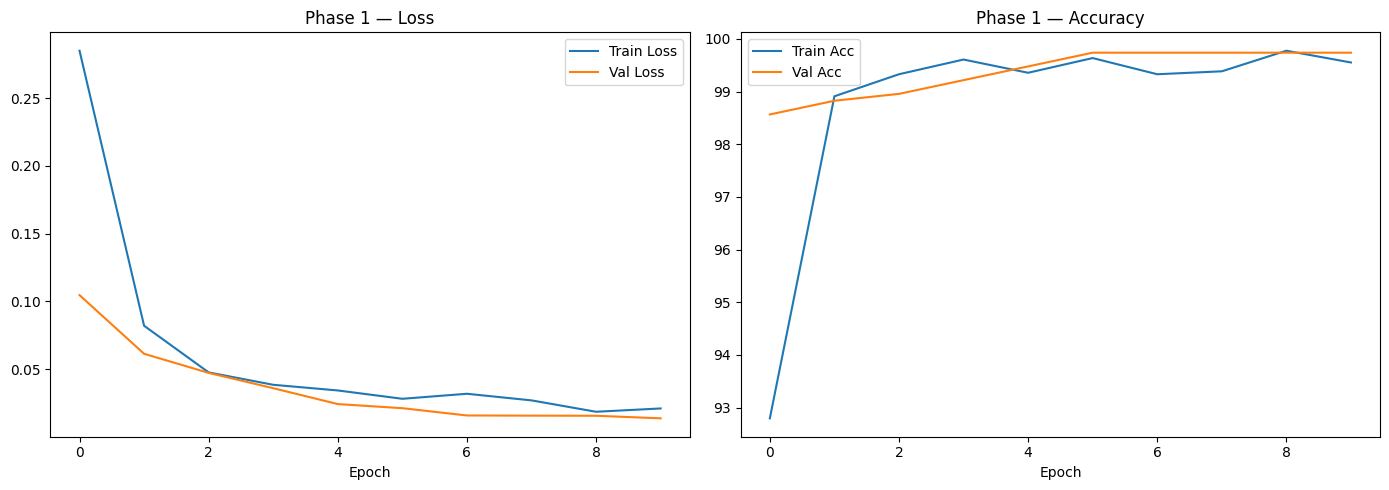

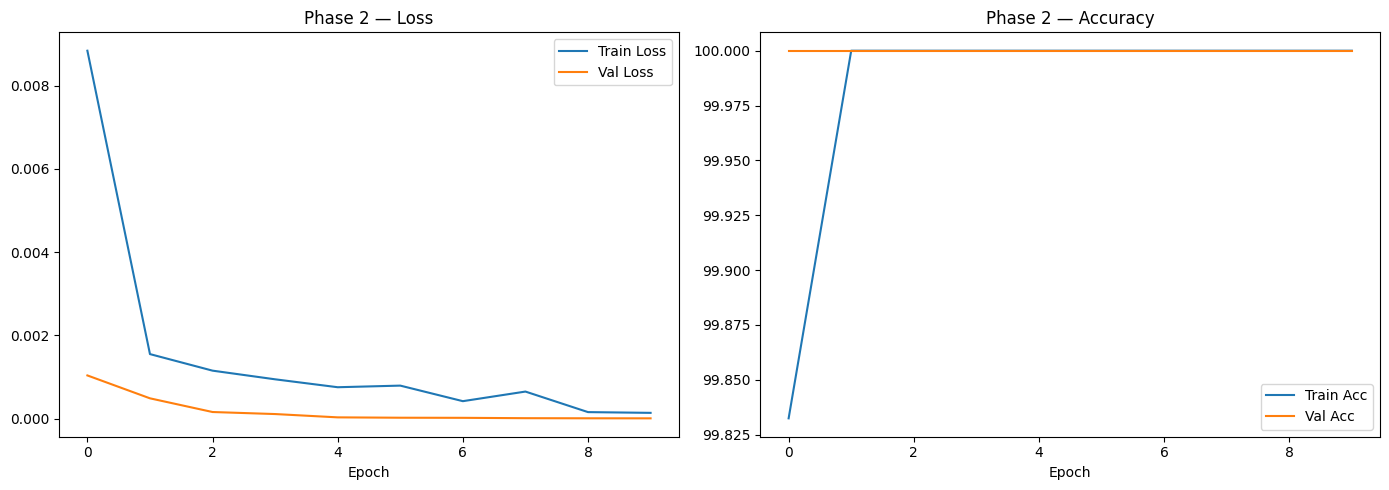

In [11]:
import matplotlib.pyplot as plt

def plot_history(history, title="Training"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(history["train_loss"], label="Train Loss")
    ax1.plot(history["val_loss"],   label="Val Loss")
    ax1.set_title(f"{title} — Loss")
    ax1.set_xlabel("Epoch")
    ax1.legend()

    ax2.plot(history["train_acc"], label="Train Acc")
    ax2.plot(history["val_acc"],   label="Val Acc")
    ax2.set_title(f"{title} — Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_phase1, "Phase 1")
plot_history(history_phase2, "Phase 2")

## Testing

Test Loss: 0.0000 | Test Accuracy: 100.00%

              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00       305
      Banana       1.00      1.00      1.00       245
       Grape       1.00      1.00      1.00       219

    accuracy                           1.00       769
   macro avg       1.00      1.00      1.00       769
weighted avg       1.00      1.00      1.00       769



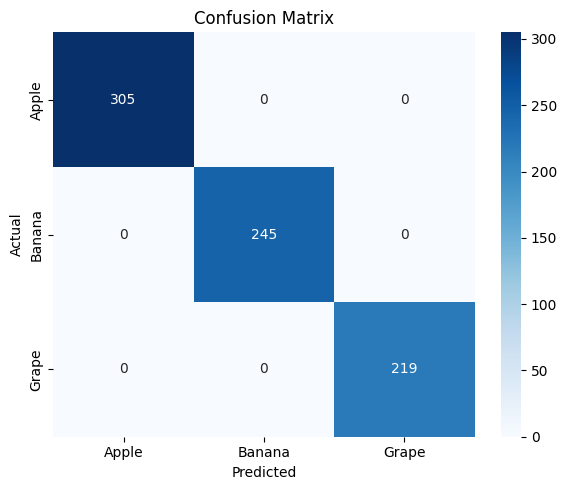

In [12]:
def evaluate_model(model, test_loader, criterion, class_names, device):
    model.eval()
    
    all_preds  = []
    all_labels = []
    test_loss, test_correct = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss    += loss.item()
            test_correct += (outputs.argmax(1) == labels).sum().item()

            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Overall stats
    test_acc  = test_correct / len(test_loader.dataset) * 100
    test_loss = test_loss / len(test_loader)
    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%\n")

    # Per class breakdown
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

# Call it
class_names = ["Apple", "Banana", "Grape"]
evaluate_model(model, test_loader, loss_function, class_names, device)